# Explore Window Level Crafted Features

In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

from src.metrics.window_metric_dataset import WindowMetricDataset, MILBagDataset
from torch.utils.data import DataLoader, Subset

In [55]:
processed_path = "data/processed"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)[cols_to_keep]
        pbar.update(1)

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:   0%|          | 0/86 [00:00<?, ?it/s]

Loading processed data:  97%|█████████▋| 83/86 [00:36<00:01,  2.28it/s]


In [4]:
validation_goups = np.random.choice(range(1, 30), size=6, replace=False)
# For current version results:
validtation_groups = np.array([18, 15,  9, 19, 23, 22])
#[1, 11, 17, 18, 27, 28]
train_groups = [g for g in range(1, 30) if (g not in validation_goups or g==8)]

train_df_dict = {key: df_dict[key] for key in df_dict.keys() if key[1] in train_groups}
val_df_dict = {key: df_dict[key] for key in df_dict.keys() if key[1] in validation_goups}

train_dataset = MILBagDataset(
    df_dict=train_df_dict, 
    grs_scores=grs_scores,
    hand="Right", 
    orig_fps=30.0,
    log_transform=False
)

val_dataset = MILBagDataset(
    df_dict=val_df_dict, 
    grs_scores=grs_scores,
    hand="Right", 
    orig_fps=30.0,
    scaler=train_dataset.scaler,
    log_transform=False
)

Generating MIL Bags: 100%|██████████| 18/18 [00:07<00:00,  2.56it/s]


In [143]:
train_dataset[0][0].shape

torch.Size([300, 7])

In [5]:
import numpy as np
import pandas as pd

# collect all feats into a list of 2D arrays
arrays = [feats for feats, _, _ in train_dataset] + \
         [feats for feats, _, _ in val_dataset]

# concatenate along time dimension
# each feats has shape (T_i, C), so this gives (sum(T_i), C)
all_data = np.concatenate(arrays, axis=0)

df_all_data = pd.DataFrame(all_data, columns=["path_length_ratio", "dimensionless_squared_jerk", "mean_curvature", "number_of_reversals", "std_of_velocity_magnitude", "total_path_length", "mean_vel"])

# if you have a "mask" column, filter as needed
df_all_data.describe()

,path_length_ratio,dimensionless_squared_jerk,mean_curvature,number_of_reversals,std_of_velocity_magnitude,total_path_length,mean_vel
count,33889.000000,33889.000000,33889.000000,33889.000000,33889.000000,33889.000000,33889.000000
mean,0.659425,0.609851,0.286518,0.099885,0.405349,0.217307,0.230051
std,1.748321,1.894114,0.862923,0.628285,1.149786,0.814842,0.845079
min,-0.404652,-0.709500,-0.662720,-1.000000,-0.597056,-0.715144,-0.708120
25%,-0.244761,-0.354578,-0.335433,-0.400000,-0.309332,-0.387665,-0.385537
50%,0.001858,-0.003559,0.004737,0.000000,-0.015287,-0.010855,-0.011858
75%,0.734845,0.635869,0.660975,0.600000,0.653313,0.578495,0.576311
max,10.000000,10.000000,7.585000,3.400000,10.000000,6.419204,6.972628


In [6]:
import torch
def mil_collate_fn(batch):
    """
    Collate function to handle variable-sized bags.
    Returns:
        bags: List of (N, 5) tensors
        labels: Tensor of shape (Batch_Size, 1)
        ids: List of identifiers
    """
    bags, labels, ids = zip(*batch)
    labels = torch.stack(labels) # Stack to (B, 1)
    return list(bags), labels, ids

In [7]:
train_loader = DataLoader(train_dataset, batch_size=13, shuffle=True, collate_fn=mil_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=mil_collate_fn)

# Attention MIL Training

In [44]:
from src.models.attention_mil import run_training
    
model, history = run_training(
    train_loader=train_loader,
    val_loader=val_loader,
    input_dim=6,
    epochs=1000,
    lr=2e-4,
)

Starting training on cpu for 1000 epochs...
Epoch | Train Loss | Val Loss   | Val MAE    | Spearman  
-----------------------------------------------------------------
1     | 89.3093     | 100.8526     | 8.9858     | 0.2288
2     | 91.8184     | 100.5592     | 8.9675     | 0.2288
3     | 84.7018     | 100.2604     | 8.9485     | 0.2288
4     | 91.3733     | 99.9561     | 8.9287     | 0.2288
5     | 89.5403     | 99.6776     | 8.9101     | 0.2288
6     | 89.1021     | 99.3835     | 8.8900     | 0.2288
7     | 91.4217     | 99.1270     | 8.8721     | 0.2288
8     | 82.1726     | 98.9391     | 8.8591     | 0.2341
9     | 82.0582     | 98.7361     | 8.8448     | 0.2341
10    | 79.0291     | 98.5496     | 8.8314     | 0.2341
11    | 88.1717     | 98.3634     | 8.8179     | 0.2341
12    | 85.1386     | 98.2021     | 8.8060     | 0.2341
13    | 86.6613     | 98.0065     | 8.7912     | 0.2234
14    | 82.4936     | 97.8556     | 8.7795     | 0.2234
15    | 80.8896     | 97.7086     | 8.7683   

In [18]:
val_df_dict.keys()

dict_keys([('2024-01-18_14-39-24', 11), ('2024-01-23_10-57-15', 22), ('2024-01-18_15-17-27', 11), ('2024-01-18_14-55-56', 11), ('2024-01-23_17-25-52', 24), ('2024-01-22_13-54-13', 17), ('2024-01-22_16-51-08', 19), ('2024-01-22_13-18-56', 17), ('2024-01-15_13-37-36', 1), ('2024-01-15_14-03-23', 1), ('2024-01-15_13-18-23', 1), ('2024-01-23_10-35-15', 22), ('2024-01-23_17-04-42', 24), ('2024-01-23_11-29-56', 22), ('2024-01-23_17-46-58', 24), ('2024-01-22_13-34-51', 17), ('2024-01-22_17-16-51', 19)])

In [ ]:
('2024-01-18_14-39-24', 11) : 47.0

In [49]:
from src.models.attention_mil import validate
import torch.nn as nn

validate(model, val_loader, nn.MSELoss(), "cpu")


{'val_loss': 53.72433470396532,
 'mae': np.float64(6.450456619262695),
 'pearson': np.float64(0.6941123200691751),
 'spearman': np.float64(0.6181630546955624)}

# BoW feature generation using the window features

In [8]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm # Assuming tqdm is available for progress tracking

# --- 1. SETUP: Replace with your actual data and scaling process ---

# Assuming this list contains all N_total x 6 feature vectors, scaled and clipped
# This is equivalent to your all_window_features_flat *after* scaling/clipping
# You will likely extract this from your MILBagDataset object's internal structure.
# Example: all_window_features_flat_scaled = np.concatenate(self.bags) 

# Assuming you already have:
# all_window_features_flat_scaled: (N_total, D) array of all window features (D=6 in your case), already scaled/clipped
# self.bags: A list of numpy arrays, where each array is (N_i, D) for video i
# self.bag_ids: A list of identifiers for each video (e.g., [('Video1', 'S1'), ('Video2', 'S2'), ...])

# --- 2. Hyperparameters ---
K_CLUSTERS = 30  # Start between 20 and 50. K=30 is a good default.
RANDOM_SEED = 42
N_INIT = 3 # Number of times to initialize K-Means

def generate_bow_features(all_window_features_flat_scaled, bags_list, bag_ids):
    """
    Applies K-Means clustering to all windows (the vocabulary) and then
    creates a histogram (BoW vector) for each video (bag).

    Args:
        all_window_features_flat_scaled (np.ndarray): (N_total, D) array of all scaled window features.
        bags_list (list): List of (N_i, D) np.ndarrays for each video.
        bag_ids (list): List of video identifiers.

    Returns:
        pd.DataFrame: A DataFrame where rows are videos and columns are BoW cluster counts.
    """
    
    # --- Step A: Train the K-Means Model (The Vocabulary) ---
    print(f"Fitting K-Means model with K={K_CLUSTERS}...")
    
    # Use MiniBatchKMeans for potentially faster training on large window sets
    kmeans = MiniBatchKMeans(
        n_clusters=K_CLUSTERS,
        init='k-means++',
        n_init=N_INIT,
        random_state=RANDOM_SEED,
        # Set max_iter higher if convergence is an issue
    )
    
    kmeans.fit(all_window_features_flat_scaled)

    all_cluster_assignments = kmeans.predict(all_window_features_flat_scaled)
    
    print("K-Means fit complete. Generating histograms...")

    # --- Step B: Generate Histograms (The BoW Feature Vectors) ---
    bow_features = []

    for bag_array, bag_id in tqdm(zip(bags_list, bag_ids), total=len(bags_list), desc="Generating BoW Histograms"):
        
        # 1. Quantization: Predict the cluster for every window in the current bag
        # Output is (N_i,) array of cluster indices (0 to K-1)
        cluster_assignments = kmeans.predict(bag_array)
        
        # 2. Histogram: Count the frequency of each cluster index
        # The result is the BoW feature vector for this video
        histogram, _ = np.histogram(
            cluster_assignments,
            bins=np.arange(K_CLUSTERS + 1), # Bins from 0 up to K_CLUSTERS
            density=False # Count, not probability
        )
        
        # Normalize the histogram by the number of windows in the video
        # This makes the feature robust to differences in video length
        total_windows = len(bag_array)
        bow_vector = histogram / (total_windows + 1e-6) # Use a small constant for safety
        
        bow_features.append(bow_vector)

    # Create column names (e.g., 'BoW_0', 'BoW_1', ...)
    col_names = [f'BoW_{i}' for i in range(K_CLUSTERS)]
    
    bow_df = pd.DataFrame(bow_features, columns=col_names, index=pd.MultiIndex.from_tuples(bag_ids, names=['VideoName', 'SurgeonID']))
    
    print("BoW feature generation complete.")
    return bow_df, all_cluster_assignments, kmeans

# Example Usage (You will integrate this into your existing pipeline):
# 1. Get the scaled data: 
#    If using your MILBagDataset, you will need to aggregate the scaled bags:
#    all_window_features_flat_scaled = np.concatenate([bag.cpu().numpy() for bag, _, _ in dataset]) 
#    bags_list = [bag.cpu().numpy() for bag, _, _ in dataset]
#    bag_ids = [bag_id for _, _, bag_id in dataset]

# 2. Run the function:
# bow_df = generate_bow_features(all_window_features_flat_scaled, bags_list, bag_ids)
# print(bow_df.head())

# 3. Hybrid Regression:
# X_global = your_global_pca_features_df
# X_hybrid = pd.concat([X_global, bow_df], axis=1)
# Train your LMM/XGBoost on X_hybrid


import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA # PCA for t-SNE initialization

def visualize_cluster_assignment(
    all_window_features_flat_scaled, 
    all_cluster_assignments, 
    K_CLUSTERS=None, 
    method='UMAP', 
    N_SAMPLES=5000,
    is_discrete=True
):
    """
    Applies either t-SNE or UMAP to the window features, coloring points by their K-Means 
    cluster assignment to validate the clustering quality.

    Args:
        all_window_features_flat_scaled (np.ndarray): (N_total, D) array of all scaled window features.
        all_cluster_assignments (np.ndarray): (N_total,) array of cluster indices (0 to K-1).
        K_CLUSTERS (int): The total number of clusters used in K-Means.
        method (str): Choose 'UMAP' or 'TSNE'. Defaults to 'UMAP'.
        N_SAMPLES (int): Number of random samples to plot (recommended for large N_total).
    """
    method = method.upper()
    if method not in ['UMAP', 'TSNE']:
        raise ValueError("Method must be 'UMAP' or 'TSNE'.")

    N_total = all_window_features_flat_scaled.shape[0]
    
    if N_total == 0:
        print("Error: Input features array is empty.")
        return

    # --- 1. Sampling for Performance ---
    if N_total > N_SAMPLES:
        print(f"Dataset size ({N_total}) is large. Sampling {N_SAMPLES} points for visualization...")
        
        rng = np.random.default_rng(seed=42)
        sample_indices = rng.choice(N_total, N_SAMPLES, replace=False)
        
        X_sample = all_window_features_flat_scaled[sample_indices]
        Y_sample = all_cluster_assignments[sample_indices]
    else:
        print(f"Using all {N_total} points for visualization.")
        X_sample = all_window_features_flat_scaled
        Y_sample = all_cluster_assignments

    # Convert to DataFrame for easier handling and plotting metadata
    df_sample = pd.DataFrame(X_sample)
    df_sample['Cluster_ID'] = Y_sample
    df_sample['Cluster_ID'] = df_sample['Cluster_ID'].astype('category')
    
    # --- 2. Dimensionality Reduction ---
    
    print(f"Computing {method} embeddings (this may take a few moments)...")
    
    if method == 'UMAP':
        reducer = umap.UMAP(
            n_neighbors=15, 
            min_dist=0.1, 
            n_components=2, 
            random_state=42
        )
        # Using tqdm for progress tracking during the fit_transform
        # UMAP can be slow, so we provide some feedback
        with tqdm(total=100, desc="UMAP Progress", unit="iter") as pbar:
            embedding = reducer.fit_transform(df_sample.drop(columns=['Cluster_ID']))
            pbar.update(100) # Simple completion flag
        title = f'UMAP of Window Features (N={len(df_sample)})'

    elif method == 'TSNE':
        # Apply PCA first for initialization, which is standard practice for t-SNE
        # and helps with convergence speed/quality, especially with higher dimensional inputs.
        pca_dim = min(50, X_sample.shape[1]) 
        X_pca = PCA(n_components=pca_dim, random_state=42).fit_transform(X_sample)
        
        tsne = TSNE(
            n_components=2, 
            learning_rate='auto', 
            init='pca', 
            perplexity=30, # Adjust perplexity (often 5 to 50)
            random_state=42, 
            n_jobs=-1
        )
        embedding = tsne.fit_transform(X_pca)
        title = f't-SNE of Window Features (N={len(df_sample)})'

    df_sample['X'] = embedding[:, 0]
    df_sample['Y'] = embedding[:, 1]
    
        # --- 3. Plotting ---
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    color_vals = df_sample['Cluster_ID'].values

    if is_discrete:
        # ----- DISCRETE CASE (clusters) -----
        unique_vals = np.unique(color_vals)
        num_vals = len(unique_vals)

        # Map values to range 0..num_vals-1 for consistent coloring
        value_to_index = {v: i for i, v in enumerate(unique_vals)}
        mapped = np.vectorize(value_to_index.get)(color_vals)

        cmap = plt.cm.get_cmap("tab20", num_vals)
        scatter = ax.scatter(
            df_sample['X'], df_sample['Y'],
            c=mapped,
            cmap=cmap,
            marker='.',
            alpha=0.8
        )

        # Discrete colorbar
        cbar = fig.colorbar(
            scatter, ax=ax, ticks=np.arange(num_vals)
        )
        cbar.set_ticklabels(unique_vals)
        cbar.set_label("Cluster ID")

    else:
        # ----- CONTINUOUS CASE (scores) -----
        scatter = ax.scatter(
            df_sample['X'], df_sample['Y'],
            c=color_vals,
            cmap="viridis",
            marker='.',
            alpha=0.8
        )
        # Continuous colorbar
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label("Score")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f'{method} Dimension 1')
    ax.set_ylabel(f'{method} Dimension 2')

    plt.tight_layout()
    plt.show()


In [9]:
# get scaled data
all_window_features_flat_scaled = np.concatenate([bag.cpu().numpy() for bag, _, _ in train_dataset] + [bag.cpu().numpy() for bag, _, _ in val_dataset])
bag_list = [bag.cpu().numpy() for bag, _, _ in train_dataset] + [bag.cpu().numpy() for bag, _, _ in val_dataset]
bag_ids = [bag_id for _, _, bag_id in train_dataset] + [bag_id for _, _, bag_id in val_dataset]
bag_scores = [score for _, score, _ in train_dataset] + [score for _, score, _ in val_dataset]

# run K means and get BoW features
bow_df, all_cluster_assignments, kmeans = generate_bow_features(all_window_features_flat_scaled, bag_list, bag_ids)

Fitting K-Means model with K=30...
K-Means fit complete. Generating histograms...


Generating BoW Histograms: 100%|██████████| 83/83 [00:00<00:00, 979.61it/s]

BoW feature generation complete.


## First check that the k-means clustering worked at window level

- Cluster feature means inspection (TO DO)
- UMAP of window features with their assigned cluser as clor label (Done) => looks like it worked quite well

Dataset size (33889) is large. Sampling 2000 points for visualization...
Computing UMAP embeddings (this may take a few moments)...


UMAP Progress:   0%|          | 0/100 [00:00<?, ?iter/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP Progress: 100%|██████████| 100/100 [00:06<00:00, 15.10iter/s]
/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_61460/3554251116.py:212: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_vals)


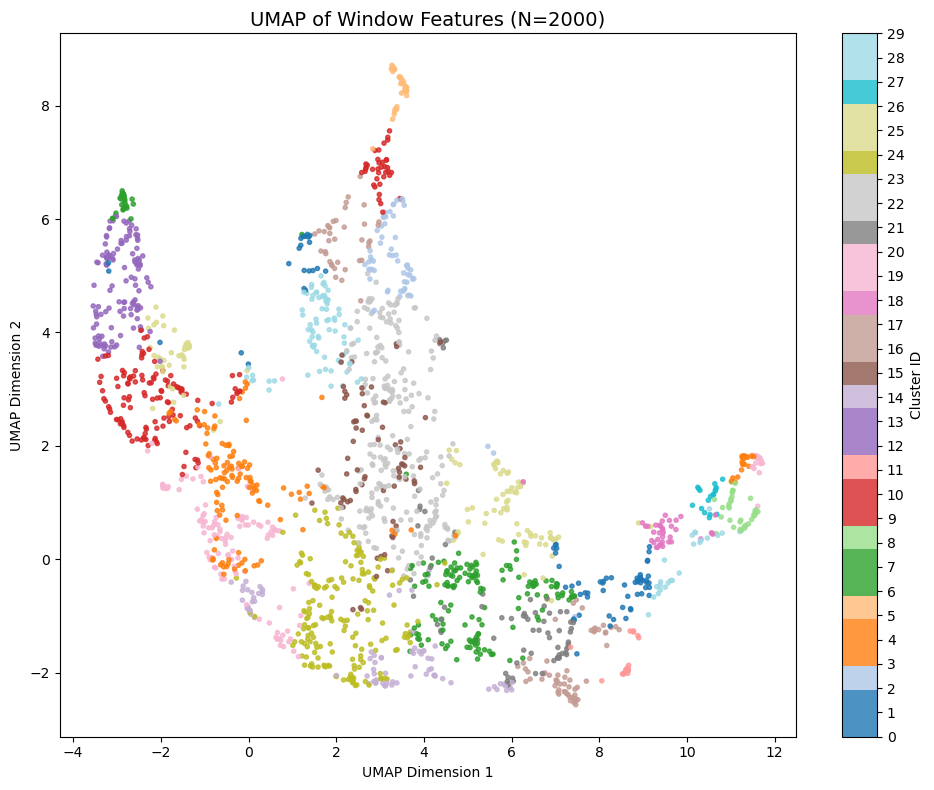

In [88]:
visualize_cluster_assignment(all_window_features_flat_scaled, all_cluster_assignments, K_CLUSTERS=K_CLUSTERS, N_SAMPLES=2000)

## UMAP of BoW Features

!! Doesn't look very promissing !!

In [116]:
bow_df.describe()

,BoW_0,BoW_1,BoW_2,BoW_3,BoW_4,BoW_5,BoW_6,BoW_7,BoW_8,BoW_9,...,BoW_40,BoW_41,BoW_42,BoW_43,BoW_44,BoW_45,BoW_46,BoW_47,BoW_48,BoW_49
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,...,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,0.040016,0.022301,0.013718,0.010455,0.022451,0.009628,0.014337,0.053188,0.015512,0.021212,...,0.001440,0.014751,0.018665,0.031683,0.034789,0.017624,0.033113,0.027034,0.009721,0.028223
std,0.021768,0.011118,0.009309,0.010181,0.013690,0.011384,0.008192,0.025178,0.009051,0.011698,...,0.003225,0.007967,0.011731,0.013561,0.016978,0.011432,0.014273,0.010751,0.009246,0.012792
min,0.003876,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004167,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.006667,0.003623,0.000000,0.003300,0.002890,0.000000,0.002959
25%,0.024968,0.014244,0.006785,0.003528,0.012737,0.000000,0.007884,0.033725,0.010185,0.013378,...,0.000000,0.010106,0.010881,0.021911,0.023739,0.008348,0.023207,0.019136,0.002695,0.018492
50%,0.036496,0.020761,0.012077,0.007634,0.021352,0.006849,0.013304,0.053150,0.013746,0.019298,...,0.000000,0.013841,0.017730,0.028986,0.031250,0.017094,0.032922,0.026570,0.007605,0.027237
75%,0.051667,0.029076,0.020067,0.014886,0.029002,0.013741,0.019849,0.068040,0.020160,0.027049,...,0.001994,0.018902,0.025478,0.040636,0.043923,0.023156,0.041519,0.033575,0.015127,0.036632
max,0.103158,0.049383,0.046440,0.051948,0.063492,0.066038,0.035484,0.113501,0.052632,0.067416,...,0.020548,0.042105,0.058621,0.064516,0.082126,0.054167,0.072183,0.050992,0.045894,0.068493


Using all 83 points for visualization.
Computing UMAP embeddings (this may take a few moments)...


UMAP Progress:   0%|          | 0/100 [00:00<?, ?iter/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
UMAP Progress: 100%|██████████| 100/100 [00:15<00:00,  6.66iter/s]


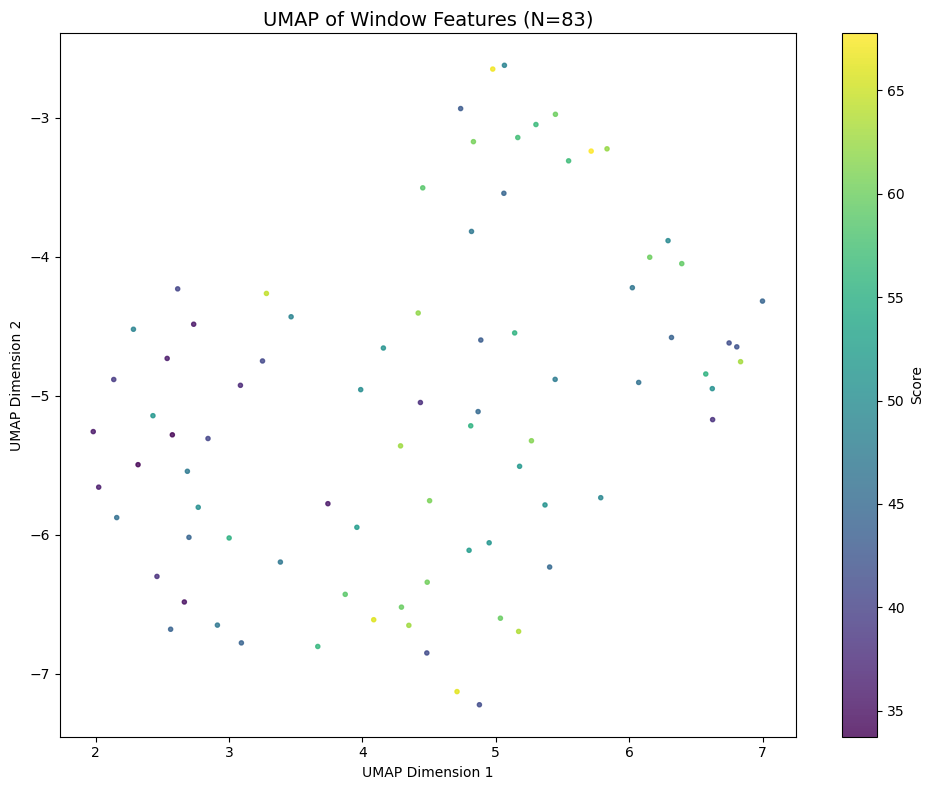

In [10]:
X_bow = bow_df.values

visualize_cluster_assignment(X_bow, np.array(bag_scores).flatten(), is_discrete=False)

# Let's have a closer look at the individual BoW features

In [11]:
# standardize the data using standard scaler
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

scaler = StandardScaler()
X_bow_scaled = scaler.fit_transform(X_bow)

scaled_bow_df = pd.DataFrame(X_bow_scaled, columns=bow_df.columns, index=bow_df.index)
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
pearson_corrs = []
spearman_corrs = []
for i in range(X_bow_scaled.shape[1]):
    pearson_corr, _ = pearsonr(X_bow_scaled[:, i], np.array(bag_scores).flatten())
    spearman_corr, _ = spearmanr(X_bow_scaled[:, i], np.array(bag_scores).flatten())
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 BoW features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]
for idx in top_pearson_indices:
    print(f"BoW_{idx}: Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 BoW features by Pearson correlation:
BoW_16: Pearson r = -0.4611, Spearman rho = -0.4941
BoW_2: Pearson r = 0.4502, Spearman rho = 0.4485
BoW_3: Pearson r = -0.4342, Spearman rho = -0.4335
BoW_23: Pearson r = 0.4226, Spearman rho = 0.3874
BoW_25: Pearson r = 0.4020, Spearman rho = 0.3758
BoW_29: Pearson r = -0.3887, Spearman rho = -0.3727
BoW_24: Pearson r = 0.3863, Spearman rho = 0.4027
BoW_17: Pearson r = 0.3858, Spearman rho = 0.4336
BoW_10: Pearson r = -0.3616, Spearman rho = -0.3322
BoW_12: Pearson r = 0.3536, Spearman rho = 0.3400
BoW_28: Pearson r = 0.3497, Spearman rho = 0.3372
BoW_13: Pearson r = 0.3324, Spearman rho = 0.2399


Using all 83 points for visualization.
Computing UMAP embeddings (this may take a few moments)...


UMAP Progress:   0%|          | 0/100 [00:00<?, ?iter/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP Progress: 100%|██████████| 100/100 [00:00<00:00, 350.18iter/s]


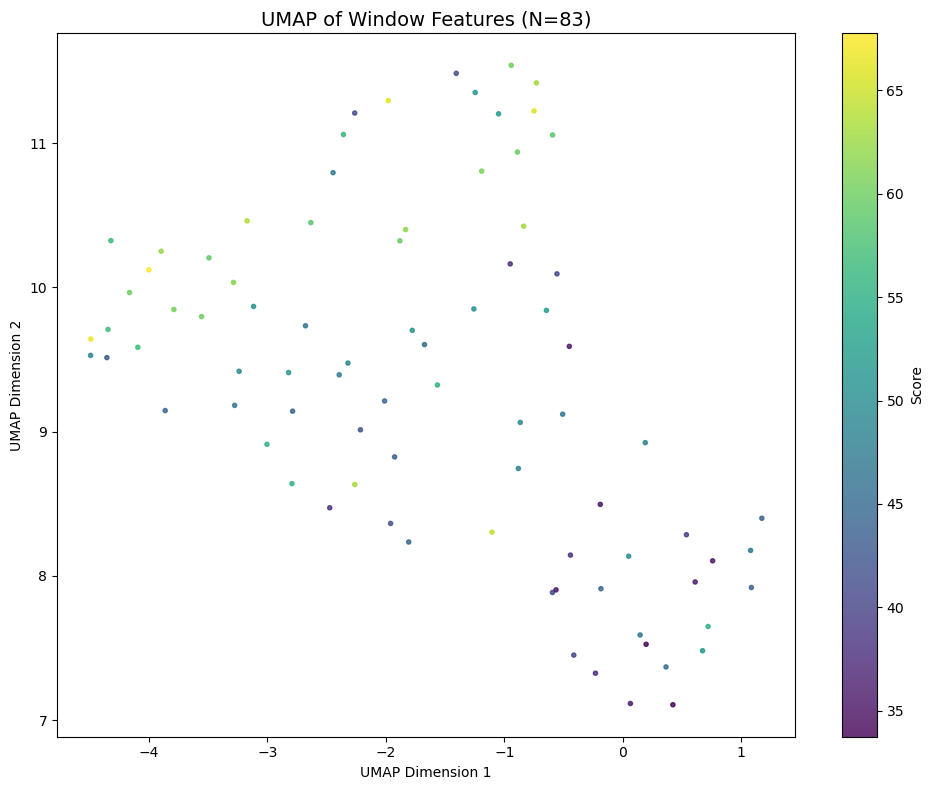

In [12]:
X_bow_filtered = X_bow[:, top_pearson_indices]
visualize_cluster_assignment(X_bow_filtered, np.array(bag_scores).flatten(), is_discrete=False)

In [13]:
# check cluster centroids for top positive and negative predictors

centroids = kmeans.cluster_centers_
feature_names = ['PathRatio', 'Jerk', 'Curvature', 'Reversals', 'StdVel', 'TotalPath', 'MeanVel']

print("--- Negative Predictors (Novice Moves) ---")
for idx in [16, 3, 29, 10]:
    print(f"Cluster {idx}: {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in [2, 23, 25, 24, 17, 12, 28, 13]:
    print(f"Cluster {idx}: {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 16: {'PathRatio': np.float32(0.2), 'Jerk': np.float32(-0.26), 'Curvature': np.float32(-0.26), 'Reversals': np.float32(0.24), 'StdVel': np.float32(0.73), 'TotalPath': np.float32(0.63), 'MeanVel': np.float32(0.63)}
Cluster 3: {'PathRatio': np.float32(-0.15), 'Jerk': np.float32(-0.38), 'Curvature': np.float32(-0.3), 'Reversals': np.float32(-0.39), 'StdVel': np.float32(0.35), 'TotalPath': np.float32(0.27), 'MeanVel': np.float32(0.27)}
Cluster 29: {'PathRatio': np.float32(0.09), 'Jerk': np.float32(0.12), 'Curvature': np.float32(0.15), 'Reversals': np.float32(0.38), 'StdVel': np.float32(-0.18), 'TotalPath': np.float32(-0.25), 'MeanVel': np.float32(-0.25)}
Cluster 10: {'PathRatio': np.float32(-0.14), 'Jerk': np.float32(-0.17), 'Curvature': np.float32(0.06), 'Reversals': np.float32(-0.3), 'StdVel': np.float32(-0.15), 'TotalPath': np.float32(-0.24), 'MeanVel': np.float32(-0.24)}

--- Positive Predictors (Expert Moves) ---
Cluster 2: {'PathRatio

# Hybrid Model : Combine top BoW features with global PCA features

In [14]:
df_total_metrics_pca = pd.read_csv("data/metrics/total_metrics_pca.csv")

df_total_metrics_pca.head(2)


,Participant Number,Case_Number,PC1,PC2,PC3,QRS_Overal
0,1,1,0.487489,-0.793460,0.334092,48.5
1,1,2,-2.287117,0.224301,0.090565,45.0


In [15]:
df_map = pd.read_csv("data/scores/vid_name_map.csv").rename(columns={"Unnamed: 0": "VideoName", "Case Number": "Case_Number"})
df_total_metrics_pca = pd.merge(df_total_metrics_pca, df_map, on=['Participant Number', 'Case_Number'])
df_total_metrics_pca

,Participant Number,Case_Number,PC1,PC2,PC3,QRS_Overal,VideoName
0,1,1,0.487489,-0.793460,0.334092,48.50,2024-01-15_13-18-23
1,1,2,-2.287117,0.224301,0.090565,45.00,2024-01-15_13-37-36
2,1,3,-1.109647,0.967259,0.037255,60.50,2024-01-15_14-03-23
3,2,1,5.351349,0.689718,-0.832712,39.25,2024-01-15_14-32-45
4,2,2,2.697762,-0.369234,-0.824595,38.00,2024-01-15_15-05-31
...,...,...,...,...,...,...,...
78,28,2,-2.111659,-0.721672,-0.144239,59.75,2024-01-24_16-04-43
79,28,3,-1.597115,-0.182899,0.211097,56.50,2024-01-24_16-21-06
80,29,1,1.829308,-0.301507,0.457147,40.75,2024-01-24_16-52-58
81,29,2,0.438817,-0.920272,0.058260,50.25,2024-01-24_17-19-03


In [50]:
scaled_bow_df

,,BoW_0,BoW_1,BoW_2,BoW_3,BoW_4,BoW_5,BoW_6,BoW_7,BoW_8,BoW_9,...,BoW_20,BoW_21,BoW_22,BoW_23,BoW_24,BoW_25,BoW_26,BoW_27,BoW_28,BoW_29
VideoName,SurgeonID,,,,,,,,,,,,,,,,,,,,,
2024-01-24_08-12-33,25,-0.189979,0.361267,-0.677286,-1.060252,-0.655749,0.141511,-0.089807,0.012880,-0.857728,0.278893,...,-0.581207,1.633698,-0.611238,1.291677,0.148599,-0.428322,0.867973,-0.922161,-0.603163,-0.310004
2024-01-18_14-39-24,11,1.463462,-0.718157,-0.745636,-0.933620,-0.024293,-0.699561,0.456161,0.281344,-0.343420,-0.719830,...,-0.649456,-0.569666,-0.611238,-0.464842,-0.486431,0.395068,1.441429,-0.389661,-0.605897,2.518906
2024-01-23_10-57-15,22,1.782535,0.055142,-0.615661,0.775102,-0.445212,0.110263,-0.021032,0.403525,-1.222877,-0.828262,...,-0.177826,-0.397186,-0.493236,-0.693487,-0.358103,-0.486472,0.471064,-0.447988,-0.673276,0.394484
2024-01-18_15-17-27,11,-0.522623,-1.012330,0.283226,-0.743653,0.534631,1.055847,0.854344,0.243138,1.055590,-0.374665,...,0.673735,1.709606,-0.100601,-0.139184,-0.314622,0.690372,-0.811931,0.514182,0.675242,-0.201793
2024-01-23_14-25-29,23,1.612410,-1.694146,-0.677286,3.356004,-0.830828,-0.330548,-1.021312,0.721863,0.033805,-0.555629,...,-1.132071,-0.780726,-0.373549,0.318214,-0.343816,-0.097299,-0.773081,-0.922161,-1.000365,0.577914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-17_16-48-38,7,-0.549852,1.241865,1.467438,0.854136,-0.928095,1.417229,-1.254549,-0.675796,2.288813,0.792738,...,0.007552,-0.834081,-0.611238,0.613888,-0.307764,2.449891,0.294691,-0.383705,1.267032,-0.754702
2024-01-15_14-32-45,2,-1.068874,0.016510,-0.493871,0.609004,-0.672238,-1.018760,1.568862,1.759935,-0.782813,-1.242692,...,0.869843,-1.319819,-0.611238,-1.457949,-0.739132,-1.051244,-0.786170,0.082808,-0.543827,2.094455
2024-01-22_14-27-29,18,-0.996729,-1.001004,-0.615206,0.237912,-0.565772,-0.698634,0.239390,3.448660,-0.600004,-1.213695,...,-0.390970,-0.932844,-0.611238,-1.622459,0.872582,0.636396,0.195280,-0.922161,-0.810033,1.695511


In [16]:
top_bow_df = scaled_bow_df.iloc[:, top_pearson_indices]
top_bow_df['Participant Number'] = [int(idx[1]) for idx in top_bow_df.index]

merged_feature_df = pd.merge(df_total_metrics_pca, top_bow_df.reset_index(), on='VideoName').drop(columns=['Participant Number_y', 'Participant Number_x'])
merged_feature_df

/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_39878/1320469613.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_bow_df['Participant Number'] = [int(idx[1]) for idx in top_bow_df.index]


,Case_Number,PC1,PC2,PC3,QRS_Overal,VideoName,SurgeonID,BoW_16,BoW_2,BoW_3,BoW_23,BoW_25,BoW_29,BoW_24,BoW_17,BoW_10,BoW_12,BoW_28,BoW_13
0,1,0.487489,-0.793460,0.334092,48.50,2024-01-15_13-18-23,1,-0.178066,-0.416768,2.113195,-0.610875,-0.931931,1.596169,0.004356,0.933546,0.236499,0.263029,-0.485474,-0.892964
1,2,-2.287117,0.224301,0.090565,45.00,2024-01-15_13-37-36,1,-0.547077,-1.054644,0.679604,-1.487945,-0.954909,-1.261147,-1.881053,2.368087,-0.097591,-1.330577,-0.750574,-0.892964
2,3,-1.109647,0.967259,0.037255,60.50,2024-01-15_14-03-23,1,-0.085673,1.613515,-0.538645,-0.070964,1.349894,-0.756060,1.813647,0.916307,-0.339931,0.937039,-0.672628,-0.892964
3,1,5.351349,0.689718,-0.832712,39.25,2024-01-15_14-32-45,2,0.389701,-0.493871,0.609004,-1.457949,-1.051244,2.094455,-0.739132,-0.830338,1.622923,-0.079175,-0.543827,-0.530648
4,2,2.697762,-0.369234,-0.824595,38.00,2024-01-15_15-05-31,2,1.469043,-0.813232,0.036137,-0.925944,-0.476818,1.238443,-1.068177,-1.833884,0.552356,-1.169187,-0.668047,-0.892964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,2,-2.111659,-0.721672,-0.144239,59.75,2024-01-24_16-04-43,28,-0.276595,-0.003293,-0.522820,-0.574245,2.537918,-0.056094,-0.141107,0.328868,0.305986,1.337629,-1.221033,-0.892964
79,3,-1.597115,-0.182899,0.211097,56.50,2024-01-24_16-21-06,28,-0.845886,1.126682,-0.072263,2.042087,0.632617,-0.841152,3.259681,-0.517375,0.366186,1.203865,0.255946,2.702480
80,1,1.829308,-0.301507,0.457147,40.75,2024-01-24_16-52-58,29,2.142079,-0.160352,0.772275,-0.694950,-1.287259,0.553861,-0.600246,-1.498152,0.628448,-0.754198,-1.038591,-0.892964
81,2,0.438817,-0.920272,0.058260,50.25,2024-01-24_17-19-03,29,0.112287,0.001480,0.279674,-0.949981,-0.096743,0.959426,-0.408325,-0.510456,0.695102,-1.241342,0.195480,-0.438250


In [51]:
# store merged feature df
top_bow_df.to_csv("data/metrics/top_BoW_video_features.csv")

In [56]:
top_bow_df.describe()

,BoW_16,BoW_2,BoW_3,BoW_23,BoW_25,BoW_29,BoW_24,BoW_17,BoW_10,BoW_12,BoW_28,BoW_13,Participant Number
count,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,83.000000
mean,-1.845913e-16,3.076522e-16,-3.966038e-16,2.942760e-17,3.317293e-16,8.025709e-18,-3.531312e-16,2.902631e-16,1.712151e-16,7.611047e-16,2.407713e-16,1.872665e-17,15.204819
std,1.006079e+00,1.006079e+00,1.006079e+00,1.006079e+00,1.006079e+00,1.006079e+00,1.006079e+00,1.006079e+00,1.006079e+00,1.006079e+00,1.006079e+00,1.006079e+00,8.499296
min,-1.693956e+00,-1.642736e+00,-1.821357e+00,-1.903794e+00,-1.497783e+00,-1.912274e+00,-1.881053e+00,-1.833884e+00,-1.665525e+00,-1.852754e+00,-1.221033e+00,-8.929640e-01,1.000000
25%,-7.144900e-01,-6.807094e-01,-7.409975e-01,-6.730423e-01,-7.580676e-01,-7.553809e-01,-6.210569e-01,-7.984122e-01,-7.377898e-01,-6.417688e-01,-8.032879e-01,-7.264554e-01,8.000000
50%,-1.199567e-01,-3.012686e-01,3.613702e-02,-2.002011e-02,-1.980910e-01,-4.786885e-03,-2.313973e-01,7.319832e-02,-1.215308e-01,-7.917482e-02,-1.449178e-01,-4.174864e-01,15.000000
75%,7.177463e-01,5.104714e-01,5.904805e-01,6.327024e-01,4.626199e-01,6.071602e-01,4.101156e-01,6.620536e-01,6.329503e-01,4.102641e-01,6.793004e-01,5.877261e-01,22.500000
max,4.012167e+00,4.149963e+00,3.356004e+00,3.517112e+00,3.697978e+00,2.518906e+00,3.259681e+00,2.914692e+00,2.496478e+00,2.971076e+00,3.476220e+00,3.214712e+00,29.000000


--- Correlation with Residuals (Base: PC1) ---
   Feature  Resid_Corr   p-value  Score_Corr  Score_p-value
14  BoW_13    0.248794  0.023327    0.332427   2.137390e-03
12  BoW_12    0.216014  0.049837    0.353618   1.040291e-03
6   BoW_23    0.197559  0.073415    0.422628   6.888330e-05
9   BoW_24    0.194713  0.077741    0.386305   3.096040e-04
13  BoW_28    0.177292  0.108836    0.349676   1.193930e-03
4    BoW_2    0.153589  0.165662    0.450178   1.953940e-05
10  BoW_17    0.032019  0.773841    0.385797   3.158086e-04
7   BoW_25    0.028189  0.800293    0.402008   1.651183e-04
1      PC2    0.021868  0.844432    0.015439   8.898232e-01
8   BoW_29    0.012353  0.911744   -0.388718   2.816667e-04
0      PC1    0.005644  0.959612   -0.744263   7.437600e-16
11  BoW_10   -0.088407  0.426747   -0.361604   7.827307e-04
5    BoW_3   -0.169051  0.126566   -0.434193   4.112859e-05
2      PC3   -0.185567  0.093039   -0.118542   2.858106e-01
3   BoW_16   -0.233027  0.034001   -0.461116   1.1487

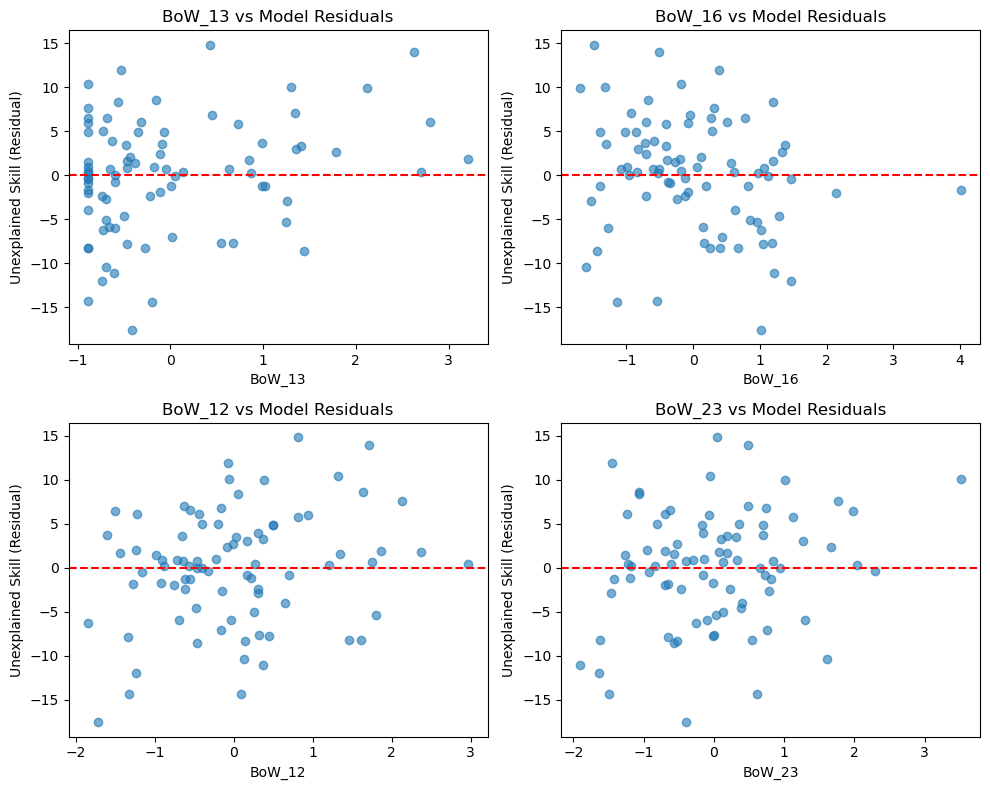

In [31]:
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

def residual_analysis(df, base_feature, candidate_features, target='QRS_Overal'):
    """
    Analyzes if candidate features explain the variance that the base_feature misses.
    """
    df_clean = df.copy().dropna(subset=[base_feature, target] + candidate_features)
    
    # 1. Train Base Model (Translational only)
    # We use LOSO (Leave-One-Subject-Out) to get 'fair' residuals
    participants = df_clean['SurgeonID'].unique()
    df_clean['base_residuals'] = 0.0
    
    for p in participants:
        train = df_clean[df_clean['SurgeonID'] != p]
        test = df_clean[df_clean['SurgeonID'] == p]
        
        # Simple Linear Regression (or Ridge) for the base model
        X_train = train[[base_feature]]
        y_train = train[target]
        
        model = Ridge(alpha=0.5)
        model.fit(X_train, y_train)
        
        # Calculate Residuals: (Actual - Predicted)
        # Positive residual means the surgeon performed better than their path length suggests
        # Negative residual means they were worse than their path length suggests
        preds = model.predict(test[[base_feature]])
        df_clean.loc[test.index, 'base_residuals'] = test[target].values - preds

    # 2. Correlate New Features with the Residuals
    print(f"--- Correlation with Residuals (Base: {base_feature}) ---")
    results = []
    for feat in candidate_features:
        r, p = pearsonr(df_clean[feat], df_clean['base_residuals'])
        scor_r, scor_p = pearsonr(df_clean[feat], df_clean[target])
        results.append({'Feature': feat, 'Resid_Corr': r, 'p-value': p, 'Score_Corr': scor_r, 'Score_p-value': scor_p})
    
    res_df = pd.DataFrame(results).sort_values('Resid_Corr', ascending=False)
    print(res_df)

    top_feats = res_df.sort_values('Resid_Corr', key=lambda x: x.abs(), ascending=False).head(4)['Feature'].tolist()
    
    # 3. Visualization
    plt.figure(figsize=(10, 8))
    for i, feat in enumerate(top_feats): # Plot top 2
        plt.subplot(2, 2, i+1)
        plt.scatter(df_clean[feat], df_clean['base_residuals'], alpha=0.6)
        plt.axhline(0, color='red', linestyle='--')
        plt.title(f"{feat} vs Model Residuals")
        plt.xlabel(feat)
        plt.ylabel("Unexplained Skill (Residual)")
    plt.tight_layout()
    plt.show()
    
    return res_df

# Example Usage:
new_candidates = ['PC1', 'PC2', 'PC3'] + ['BoW_16', 'BoW_2', 'BoW_3', 'BoW_23', 'BoW_25', 'BoW_29', 'BoW_24', 'BoW_17', 'BoW_10', 'BoW_12', 'BoW_28', 'BoW_13']
analysis_results = residual_analysis(merged_feature_df, 'PC1', new_candidates)

Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 311.50it/s]


          HYBRID MODEL (RIDGE) LOSOCV RESULTS
Overall Correlation (R): 0.7382
Overall MAE: 4.8867
Overall Std Dev of Errors: 3.8964

--- Per-Fold Performance Summary ---
           Train_MAE   Test_MAE  Test_Corr
SurgeonID                                 
1           4.418828   6.800558  -0.059519
2           4.530136   4.833141   0.857366
3           4.318705  11.628065  -0.006716
4           4.528015   3.885240   0.017643
5           4.473416   5.236633   0.804991
6           4.628553   1.426968   0.919719
7           4.321983  10.198919  -0.845534
9           4.483717   6.466306  -0.419310
10          4.621720   1.873687   0.842003
11          4.654187   0.758508   0.947120
12          4.615936   2.022616   0.911906
13          4.543601   3.729476   0.462824
14          4.496043   7.070238  -0.003346
15          4.506818   5.821951   0.974165
16          4.288976   9.993119  -0.954284
17          4.593493   2.074955   0.929518
18          4.456428   5.588052   0.951223
19          

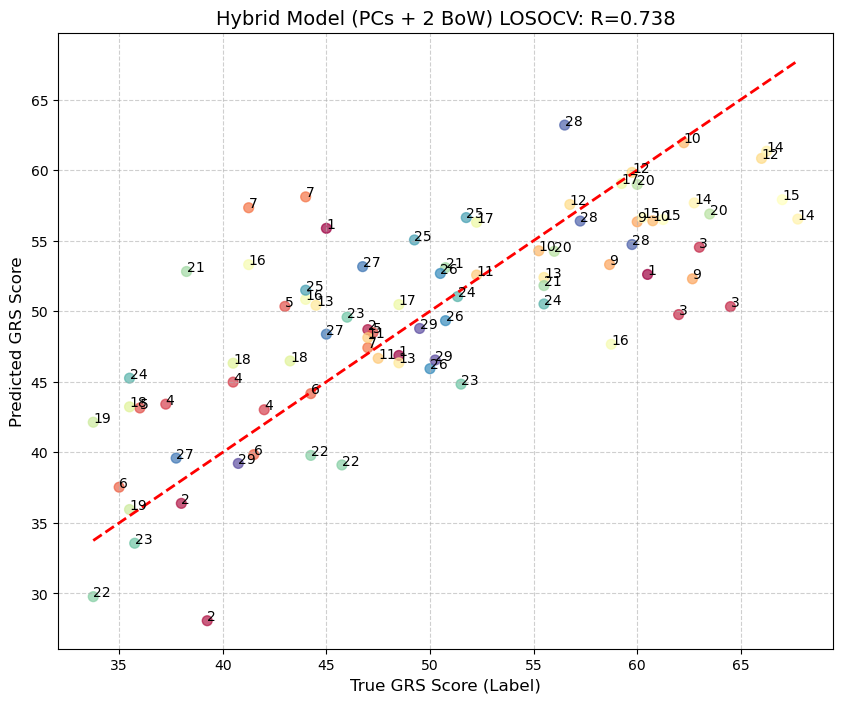

In [54]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data (Code adapted from your input) ---

# --- IMPORTANT ASSUMPTIONS ---
# 1. merged_feature_df is available and correctly indexed.
# 2. 'QRS_Overal' is the column for the true scores (y).
# 3. 'Participant Number' is the column for SurgeonID.
# 4. Feature columns are PC1, PC2, PC3, BoW_2, BoW_20.
# ------------------------------

feature_cols = [col for col in ['PC1', 'BoW_16', 'BoW_13', 'BoW_23']]#, 'BoW_19', 'BoW_22', 'BoW_7', 'BoW_26', 'BoW_25]
X = merged_feature_df[feature_cols].values
y = merged_feature_df['QRS_Overal'].values

# Extract the Surgeon IDs for the folds
surgeon_ids = merged_feature_df['SurgeonID'].values # Assuming 'Participant Number' holds the unique surgeon/participant identifier

unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []
fold_results = {} # To store results per fold

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

# We will collect fold-level predictions for plotting
all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []


for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    # 3. Train Model
    # Using the optimized alpha=0.5
    model = Ridge(alpha=0.5) 
    model.fit(X_train, y_train)
    
    # Predict and store
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Fold Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_corr, _ = pearsonr(y_test, y_test_pred)
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_Corr': test_corr
    }
    
    # Store results for overall metrics and plotting
    predictions.extend(y_test_pred)
    true_scores.extend(y_test)
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate and Print Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

# Create a DataFrame for per-fold results
fold_results_df = pd.DataFrame.from_dict(fold_results, orient='index')
fold_results_df.index.name = 'SurgeonID'

print("\n=================================================")
print("          HYBRID MODEL (RIDGE) LOSOCV RESULTS")
print("=================================================")
print(f"Overall Correlation (R): {hybrid_corr:.4f}")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"\n--- Per-Fold Performance Summary ---")
print(fold_results_df)

# --- 5. Visualization ---
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    all_fold_true, 
    all_fold_preds, 
    c=all_fold_surgeons, # Color by surgeon ID
    cmap='Spectral', 
    label='Predicted Scores',
    s=50,
    alpha=0.7
)

for i, sid in enumerate(surgeon_ids):
    plt.annotate(f'{sid}', (all_fold_true[i], all_fold_preds[i]))

# Diagonal Line (Perfect prediction)
plt.plot(
    [min(final_true_scores), max(final_true_scores)], 
    [min(final_true_scores), max(final_true_scores)], 
    'r--', 
    lw=2,
    label='Ideal Prediction (y=x)'
)

plt.xlabel("True GRS Score (Label)", fontsize=12)
plt.ylabel("Predicted GRS Score", fontsize=12)
plt.title(f"Hybrid Model (PCs + 2 BoW) LOSOCV: R={hybrid_corr:.3f}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [122]:
top_pearson_indices

array([20, 41, 44, 13, 45, 35, 31, 34,  2,  6,  7, 11])

In [139]:
# test that the difference in score for the different case numbers is significant
import scipy.stats as stats
case_numbers = merged_feature_df['Case_Number'].values
scores = merged_feature_df['QRS_Overal'].values
anova_result = stats.f_oneway(*(scores[case_numbers == cn] for cn in np.unique(case_numbers)))
print(f"ANOVA result across case numbers: F-statistic = {anova_result.statistic:.4f}, p-value = {anova_result.pvalue:.4e}")

ANOVA result across case numbers: F-statistic = 1.8851, p-value = 1.5850e-01


In [138]:
stats.levene(
    *(scores[case_numbers == cn] for cn in np.unique(case_numbers))
)



LeveneResult(statistic=np.float64(0.3956602917095992), pvalue=np.float64(0.6745454229532892))

In [123]:
# check colinearity between PC features and BoW features
# what is the correlation between PC1, PC2, PC3 and the top BoW features
for pc_col in ['PC1', 'PC2', 'PC3']:
    for bow_col in [col for col in top_bow_df.columns if col.startswith('BoW_')]:
        pearson_corr, _ = pearsonr(merged_feature_df[pc_col], merged_feature_df[bow_col])
        spearman_corr, _ = spearmanr(merged_feature_df[pc_col], merged_feature_df[bow_col])
        print(f"{pc_col} vs {bow_col}: Pearson r = {pearson_corr:.4f}, Spearman rho = {spearman_corr:.4f}")

PC1 vs BoW_9: Pearson r = -0.4185, Spearman rho = -0.5035
PC1 vs BoW_19: Pearson r = -0.4598, Spearman rho = -0.4568
PC1 vs BoW_22: Pearson r = -0.4581, Spearman rho = -0.4531
PC1 vs BoW_7: Pearson r = 0.4117, Spearman rho = 0.4544
PC1 vs BoW_26: Pearson r = -0.4769, Spearman rho = -0.5079
PC1 vs BoW_25: Pearson r = -0.4120, Spearman rho = -0.3930
PC1 vs BoW_0: Pearson r = 0.3469, Spearman rho = 0.4041
PC1 vs BoW_13: Pearson r = -0.3352, Spearman rho = -0.3524
PC1 vs BoW_18: Pearson r = 0.4741, Spearman rho = 0.3933
PC1 vs BoW_11: Pearson r = 0.4199, Spearman rho = 0.4150
PC1 vs BoW_8: Pearson r = -0.2376, Spearman rho = -0.2244
PC1 vs BoW_10: Pearson r = 0.3230, Spearman rho = 0.2990
PC2 vs BoW_9: Pearson r = 0.3529, Spearman rho = 0.2778
PC2 vs BoW_19: Pearson r = 0.3096, Spearman rho = 0.2511
PC2 vs BoW_22: Pearson r = 0.3275, Spearman rho = 0.3072
PC2 vs BoW_7: Pearson r = -0.1587, Spearman rho = -0.1540
PC2 vs BoW_26: Pearson r = 0.2527, Spearman rho = 0.3161
PC2 vs BoW_25: Pearso